# EDA on CHAPA Chapter 40B Application Data from 2021 to 2023, Visualization focused
Author: Madison Woo

**Dataset:** TOUCHABLE CHAPA Chapter 40B Application Data 2021-2023 & 10|2023-05|2025 (https://docs.google.com/spreadsheets/d/1xcW0qveqOPD-1JvJX1jaSJjPyCVVMGbY/edit?gid=1443288301#gid=1443288301)

**Sheet used:** `Geocoded Kayla 2021-2023`

**Instruction**: Download the xlsx file above and move it to the `ds-chapa-affordable-housing/fa25-team-a/data` folder, then run the cells below

## Getting count of applicants 

In [1]:
import pandas as pd 

# load data
file_path = "../data/TOUCHABLE CHAPA Chapter 40B Application Data 2021-2023 & 10_2023-05_2025.xlsx"
df = pd.read_excel(file_path, sheet_name="Geocoded Kayla 2021-2023")

# counting how many applicants applied to multiple properties 
repeated_ids = (df['ID Number'].value_counts() > 1).sum()
print("Number of repeated IDs:", repeated_ids)

# counting total number of applicants 
id_count = (df['ID Number'].value_counts()).sum()
print('Total amount of applications:', id_count)

Number of repeated IDs: 35
Total amount of applications: 380


## Analyzing applicant demographics 

In [2]:
all_applicants = df

# get ids that appear more than once
id_counts = df['ID Number'].value_counts()
repeat_ids = id_counts[id_counts > 1].index

# creating a subset of repeat applicants 
repeat_applicants = df[df['ID Number'].isin(repeat_ids)].drop_duplicates(subset = 'ID Number')

# getting demographics of applicants who applied multiple times and all applicants 
race_repeat_counts = repeat_applicants['Census Race'].value_counts()
race_all_counts = all_applicants['Census Race'].value_counts()

# seeing values 
print('Repeat Applicant Demographics:')
print(race_repeat_counts)
print('All Applicant Demographics:')
print(race_all_counts)

Repeat Applicant Demographics:
Census Race
White alone                        20
Black or African American alone     7
Asian alone                         5
Unknown                             3
Name: count, dtype: int64
All Applicant Demographics:
Census Race
White alone                                215
Unknown                                     71
Asian alone                                 45
Black or African American alone             43
White; Black or African American             3
American Indian and Alaska Native alone      2
Some Other Race alone                        1
Name: count, dtype: int64


## Creating visualizations 

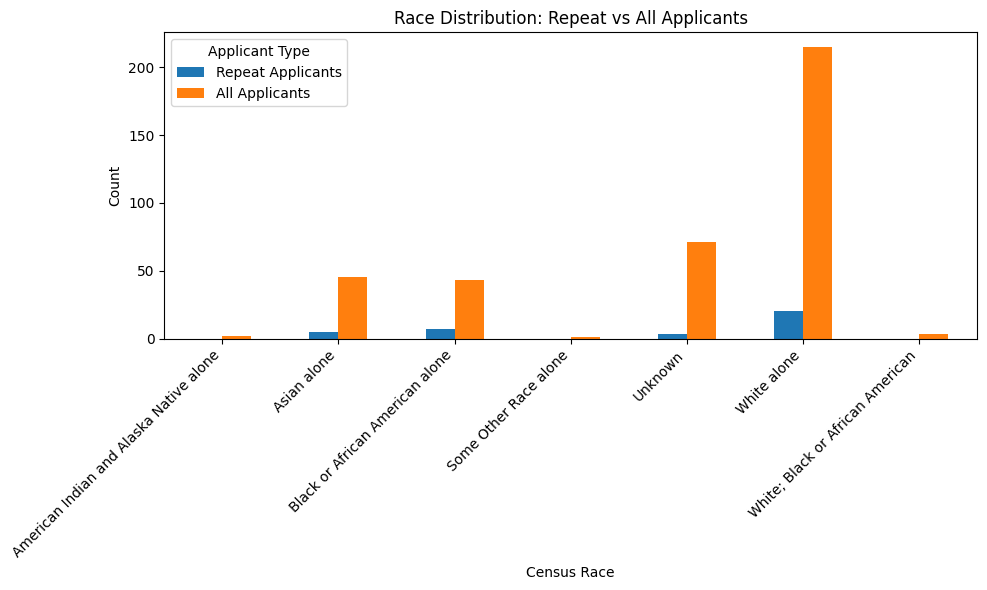

In [3]:
import matplotlib.pyplot as plt

# combine into one DataFrame for plotting
race_compare = pd.DataFrame({
    'Repeat Applicants': race_repeat_counts,
    'All Applicants': race_all_counts
# replace missing races with 0 counts
}).fillna(0)  

# plot side by side bars  
race_compare.plot(kind = 'bar', figsize = (10,6))
plt.title('Race Distribution: Repeat vs All Applicants')
plt.xlabel('Census Race')
plt.ylabel('Count')
plt.xticks(rotation = 45, ha = 'right')
plt.legend(title = 'Applicant Type')
plt.tight_layout()
plt.show()

This graph shows the race distribution between repeat applicants vs. all applicants. White and Black applicants have the highest frequency of repeat applications. 

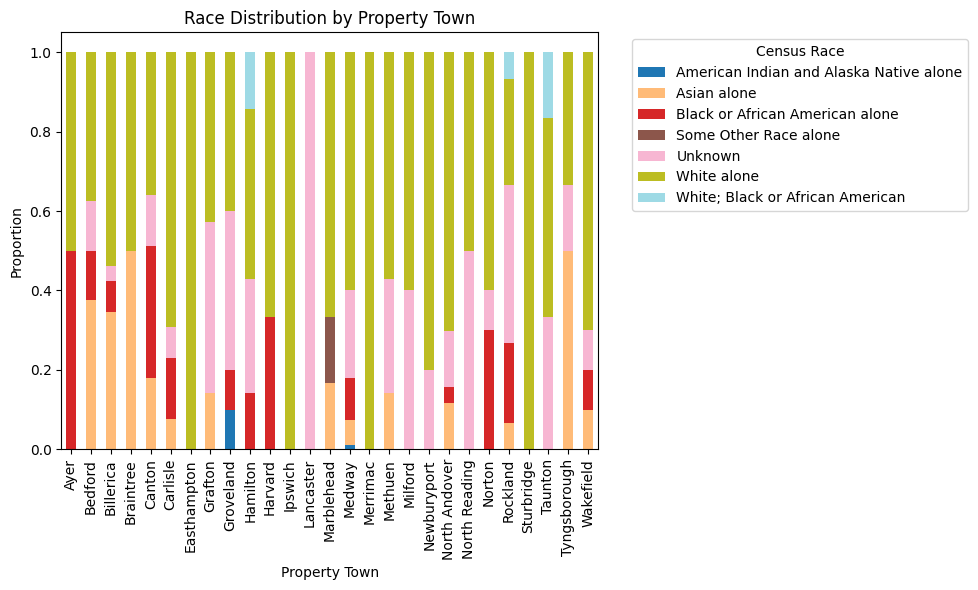

In [4]:
# combine into one DataFrame for plotting
race_prop = (
    df.groupby('Property Town')['Census Race']
      .value_counts(normalize = True)
      .unstack(fill_value = 0)
)

# plot proportion of the applicant demographics to where they applied to 
race_prop.plot(kind = 'bar', stacked = True, figsize = (10,6), colormap = 'tab20')
plt.title('Race Distribution by Property Town')
plt.xlabel('Property Town')
plt.ylabel('Proportion')
plt.legend(title = 'Census Race', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

This graph shows the race distribution by property town. Easthampton, Ipswich, Merrimac, and Ayer had the highest numbers of White and Black applicants, respectively.

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_31289/1471481961.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'Property Town', order = town_order, palette='Set2')


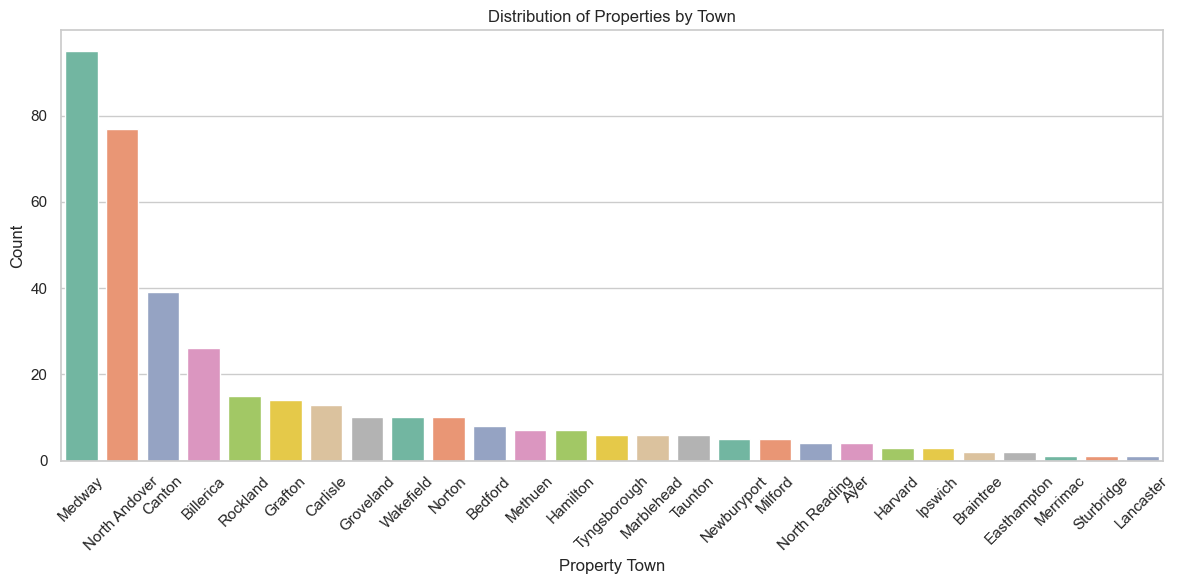

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# visual style 
sns.set_theme(style = "whitegrid")

# distribution of property towns
plt.figure(figsize = (12,6))
town_order = df['Property Town'].value_counts().index
sns.countplot(data = df, x = 'Property Town', order = town_order, palette='Set2')
plt.title("Distribution of Properties by Town")
plt.xticks(rotation = 45)
plt.xlabel("Property Town")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

This shows the distribution of properties available to apply to by the town for the 2021-2023 data. It is clear that Medway has the most amount of properties, followed by North Andover.

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_31289/3858892315.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, y = 'CHAPA Race/Ethnicity', order = race_order, palette='muted')


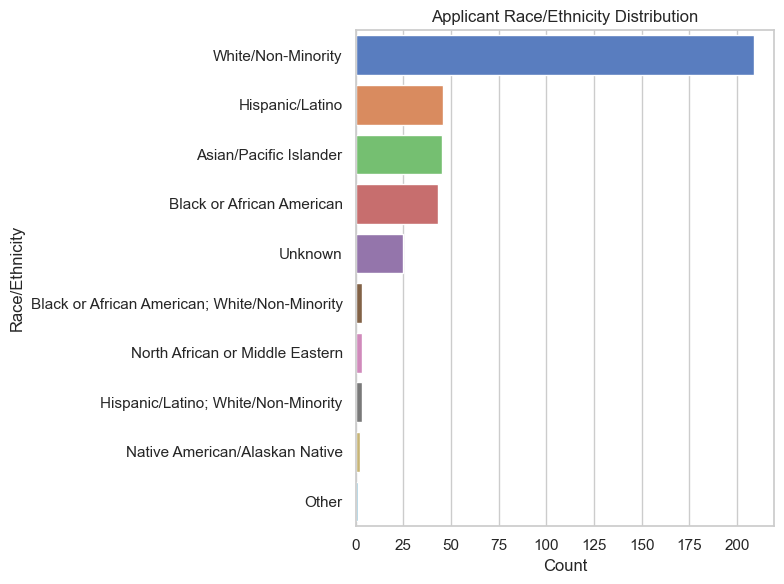

In [10]:
# distribution of applicant race/ethnicity
plt.figure(figsize = (8,6))
race_order = df['CHAPA Race/Ethnicity'].value_counts().index
sns.countplot(data = df, y = 'CHAPA Race/Ethnicity', order = race_order, palette='muted')
plt.title("Applicant Race/Ethnicity Distribution")
plt.xlabel("Count")
plt.ylabel("Race/Ethnicity")
plt.tight_layout()
plt.show()

The applicant race/ethnicity count is shown in this chart. A majority of the applicants are White/Non-Minority. 

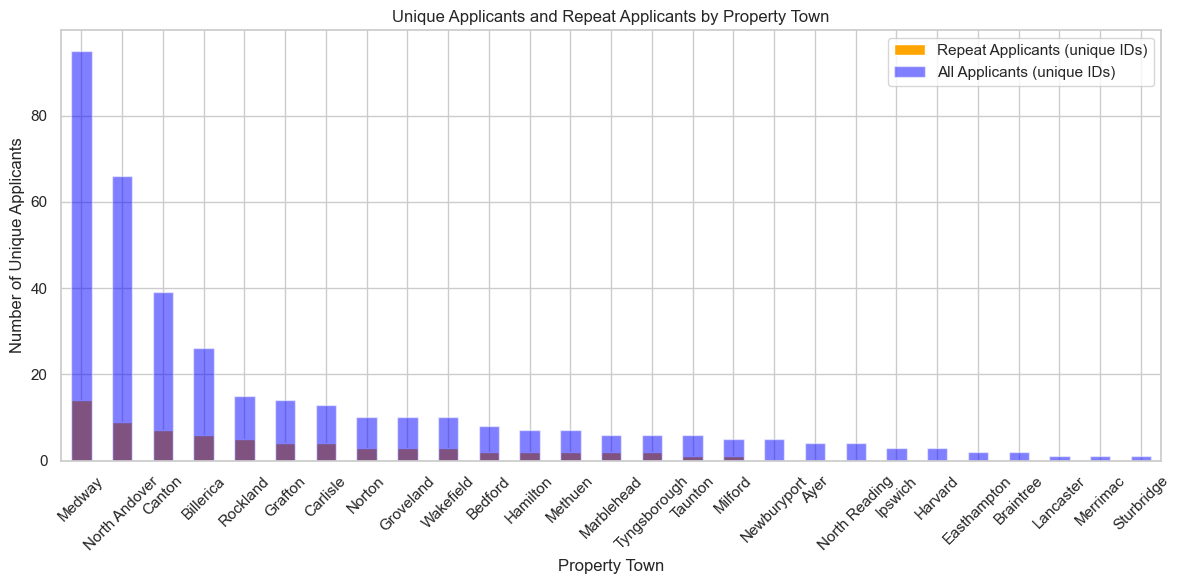

In [15]:
# count number of applications per ID 
app_counts = df['ID Number'].value_counts()
df['repeat_applicant'] = df['ID Number'].map(app_counts) > 1

# unique repeat applicant counts by property town
repeat_town_counts = df[df['repeat_applicant']].groupby('Property Town')['ID Number'].nunique().sort_values(ascending = False)
all_town_counts = df.groupby('Property Town')['ID Number'].nunique().sort_values(ascending = False)

plt.figure(figsize = (12,6))
repeat_town_counts.plot(kind = 'bar', color = 'orange', label = 'Repeat Applicants (unique IDs)')
all_town_counts.plot(kind = 'bar', color = 'blue', alpha = 0.5, label = 'All Applicants (unique IDs)')
plt.title("Unique Applicants and Repeat Applicants by Property Town")
plt.ylabel("Number of Unique Applicants")
plt.xlabel("Property Town")
plt.xticks(rotation = 45)
plt.legend()
plt.tight_layout()
plt.show()

This chart analyzes repeat vs. all applicants. There is a clear trend between property pool and number of applications received for that property; some towns/cities receive significantly more Repeat Applicants

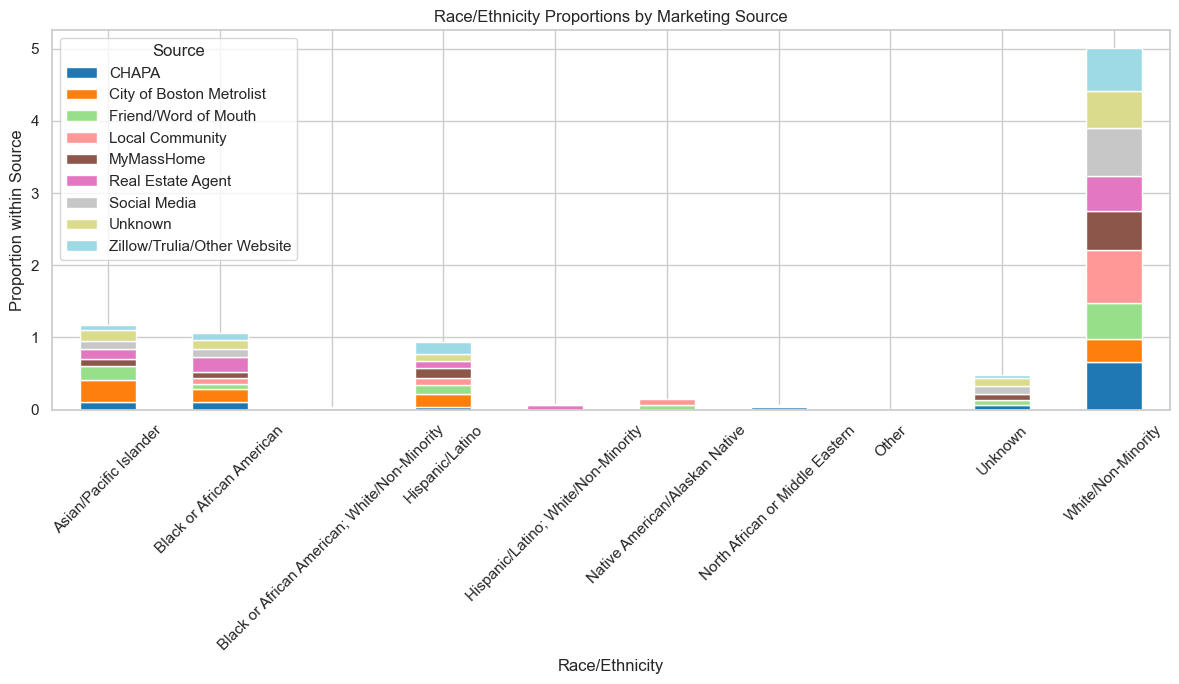

In [16]:
# race counts by Source
race_source_counts = df.groupby(['Source', 'CHAPA Race/Ethnicity']).size().unstack(fill_value = 0)

# normalize per source to get proportions
race_source_props = race_source_counts.div(race_source_counts.sum(axis = 1), axis = 0)

# plot race proportions per Source
race_source_props.T.plot(kind = 'bar', stacked = True, figsize = (12,7), colormap = 'tab20')
plt.title("Race/Ethnicity Proportions by Marketing Source")
plt.ylabel("Proportion within Source")
plt.xlabel("Race/Ethnicity")
plt.xticks(rotation = 45)
plt.legend(title = 'Source')
plt.tight_layout()
plt.show()

Race/ethnicity proportions by marketing source are shown here. This tells us which marketing source reached which race demographic of applicants. Zillow/Trulia/Other Website seems to be the largest marketing source for White/Non-Minority and City of Boston Metrolist for Pacific Islander, Black or African American, and Hispanic/Latino. 